<a href="https://colab.research.google.com/github/ibrohim747/REVIT_API_BENCHMARK/blob/main/Cloude_Type.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/Daily/Test_Revit_Types/BenchmarkResults.csv'
df = pd.read_csv(path)

In [ ]:
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
    "axes.labelsize":    10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "figure.dpi":        110,
})

# Colors by representation type — used across all sections
C = {
    "RevitAPI":    "#e05252",
    "ClassDouble": "#4e79a7",
    "ClassFloat":  "#76b7b2",
    "Struct":      "#59a14f",
    "GeomStruct":  "#f28e2b",
    "MetaStruct":  "#b07aa1",
    "Tuple":       "#ff9da7",
}

CSV_PATH = "/content/drive/MyDrive/Daily/Test_Revit_Types/BenchmarkResults.csv"
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig", parse_dates=["RunDateTime"])
print(f"Loaded {len(df)} runs  |  columns: {len(df.columns)}")
print(f"Period: {df['RunDateTime'].min()}  →  {df['RunDateTime'].max()}")

# Helpers
def mean(col):  return df[col].mean()
def std(col):   return float(df[col].std()) if len(df) > 1 else 0.0
def best_idx(vals, lower=True): return int(np.argmin(vals) if lower else np.argmax(vals))

def annotate_hbars(ax, bars, means, stds, best, unit="ms", fmt=".2f"):
    for i, (bar, m, s) in enumerate(zip(bars, means, stds)):
        label = f"{m:{fmt}} {unit}" + (" ★" if i == best else "")
        ax.text(m + s + max(means) * 0.02, bar.get_y() + bar.get_height() / 2,
                label, va="center", fontsize=8.5,
                color="#1a7a1a" if i == best else "#333",
                fontweight="bold" if i == best else "normal")

def annotate_vbars(ax, bars, means, stds, best, unit="ms", fmt=".2f"):
    for i, (bar, m, s) in enumerate(zip(bars, means, stds)):
        label = ("★ " if i == best else "") + f"{m:{fmt}}"
        ax.text(bar.get_x() + bar.get_width() / 2, m + s + max(means) * 0.02,
                label, ha="center", va="bottom", fontsize=8.5,
                color="#1a7a1a" if i == best else "#333",
                fontweight="bold" if i == best else "normal")

Loaded 30 runs  |  columns: 64
Period: 2026-03-27 09:40:42  →  2026-03-27 10:58:08


## 1. Memory Layout Sizes
Struct and Struct+Meta+Geom report exact values via `Marshal.SizeOf`.
Class — estimated: 16-byte object header + fields.


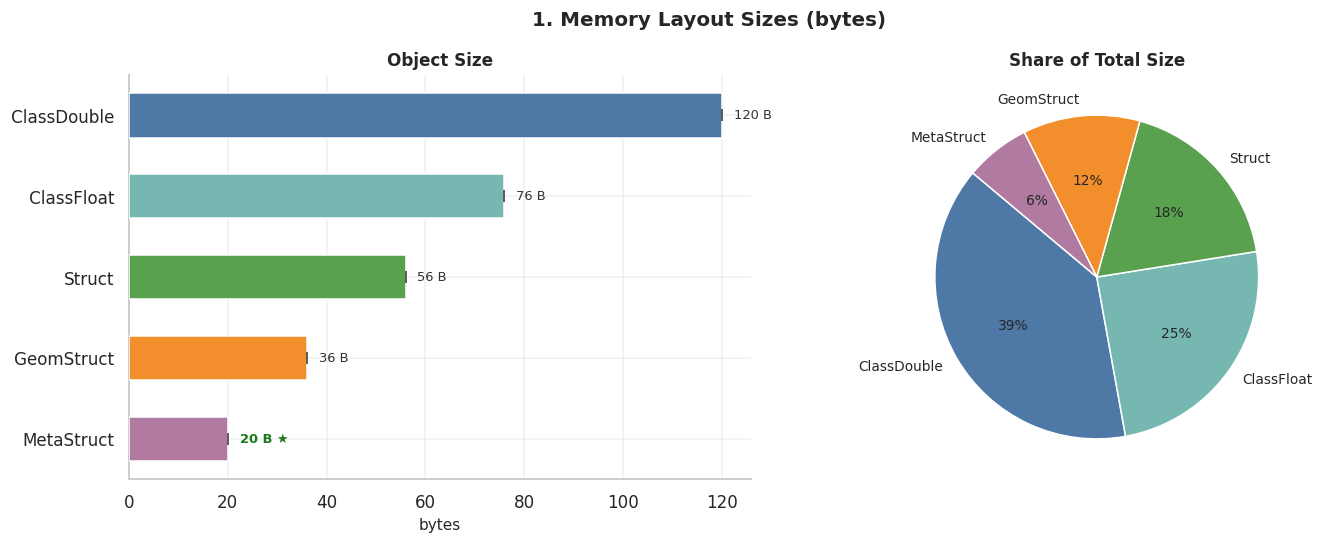

Actual values (bytes):
  ClassDouble    120 B
  ClassFloat     76 B
  Struct         56 B
  GeomStruct     36 B
  MetaStruct     20 B

Geom(36) + Meta(20) = 56 B  vs  Struct(56) B


In [ ]:
cols   = ["Sz_ClassDouble_bytes","Sz_ClassFloat_bytes",
           "Sz_Struct_bytes","Sz_GeomStruct_bytes","Sz_MetaStruct_bytes"]
labels = ["ClassDouble","ClassFloat","Struct","GeomStruct","MetaStruct"]
colors = [C["ClassDouble"], C["ClassFloat"],
          C["Struct"],   C["GeomStruct"],  C["MetaStruct"]]
means  = [mean(c) for c in cols]
stds   = [std(c)  for c in cols]
best   = best_idx(means)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("1. Memory Layout Sizes (bytes)", fontsize=13, fontweight="bold")

# Horizontal bar
y    = np.arange(len(labels))
bars = ax1.barh(y, means, xerr=stds, color=colors, height=0.55,
                error_kw=dict(ecolor="#555", capsize=4), zorder=3)
annotate_hbars(ax1, bars, means, stds, best, unit="B", fmt=".0f")
ax1.set_yticks(y); ax1.set_yticklabels(labels); ax1.invert_yaxis()
ax1.set_xlabel("bytes"); ax1.set_title("Object Size")

# Pie chart
ax2.pie(means, labels=labels, colors=colors, autopct="%1.0f%%",
        startangle=140, textprops={"fontsize": 9})
ax2.set_title("Share of Total Size")

plt.tight_layout()
plt.savefig("sec1_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

print("Actual values (bytes):")
for l, m in zip(labels, means):
    print(f"  {l:<14} {m:.0f} B")
print(f"\nGeom({means[3]:.0f}) + Meta({means[4]:.0f}) = {means[3]+means[4]:.0f} B  vs  Struct({means[2]:.0f}) B")

## 2. Function A — transform + √ (1 000 000 iterations)
> **Surprise:** ClassFloat is *slower* than ClassDouble — float operations on x64 JIT
> are promoted to double, adding overhead.

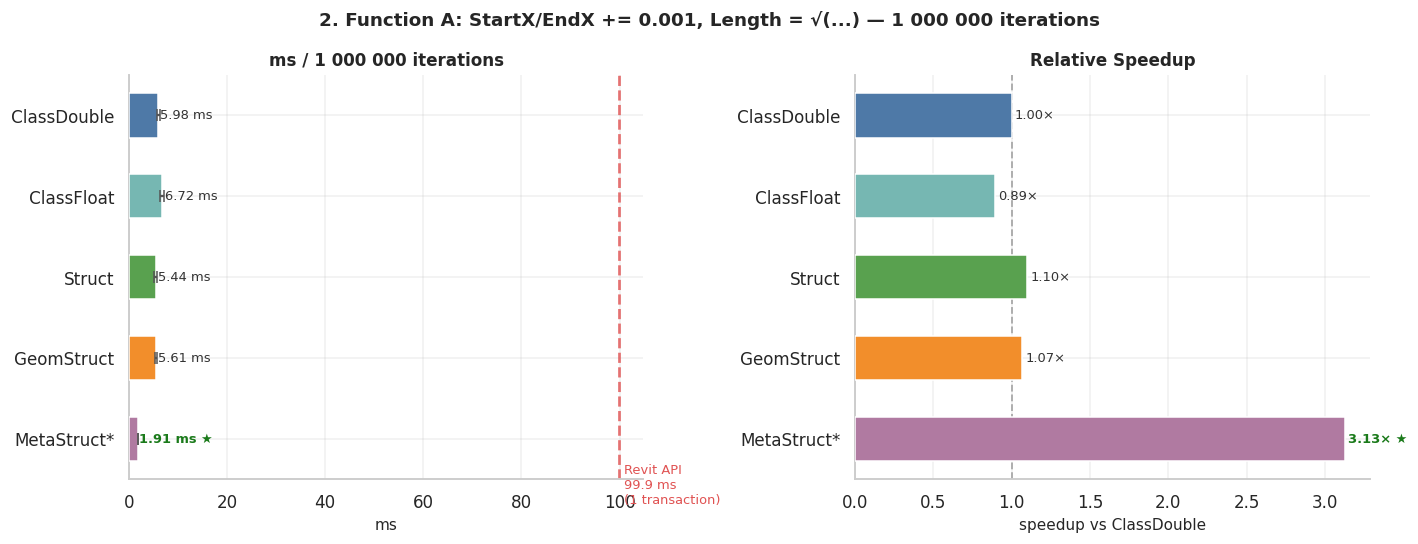

* MetaStruct: only BaseOffset += 0.001 (no √) — different compute workload

Revit API (99.9 ms) = 1 real transaction. CLR loop — incomparable scenarios.


In [ ]:
cols   = ["FuncA_ClassDouble_ms","FuncA_ClassFloat_ms",
           "FuncA_Struct_ms","FuncA_GeomStruct_ms","FuncA_MetaStruct_ms"]
labels = ["ClassDouble","ClassFloat","Struct","GeomStruct","MetaStruct*"]
colors = [C["ClassDouble"],C["ClassFloat"],C["Struct"],C["GeomStruct"],C["MetaStruct"]]
means  = [mean(c) for c in cols]
stds   = [std(c)  for c in cols]
best   = best_idx(means)
revit  = mean("FuncA_RevitAPI_ms")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("2. Function A: StartX/EndX += 0.001, Length = √(...) — 1 000 000 iterations",
             fontsize=12, fontweight="bold")

y    = np.arange(len(labels))
bars = ax1.barh(y, means, xerr=stds, color=colors, height=0.55,
                error_kw=dict(ecolor="#555", capsize=4), zorder=3)
annotate_hbars(ax1, bars, means, stds, best)
ax1.set_yticks(y); ax1.set_yticklabels(labels); ax1.invert_yaxis()
ax1.set_xlabel("ms")

# Revit API reference line
ax1.axvline(revit, color=C["RevitAPI"], lw=1.8, ls="--", alpha=0.8)
ax1.text(revit * 1.01, len(labels) - 0.7,
         f"Revit API\n{revit:.1f} ms\n(1 transaction)",
         color=C["RevitAPI"], fontsize=8.5, va="top")
ax1.set_title("ms / 1 000 000 iterations")

# Speedup vs ClassDouble
base     = means[0]
speedups = [base / m for m in means]
bars2    = ax2.barh(y, speedups, color=colors, height=0.55, zorder=3)
for i, sp in enumerate(speedups):
    marker = " ★" if i == best else ""
    ax2.text(sp + 0.02, i, f"{sp:.2f}×{marker}", va="center", fontsize=8.5,
             color="#1a7a1a" if i == best else "#333",
             fontweight="bold" if i == best else "normal")
ax2.axvline(1.0, color="#aaa", lw=1.2, ls="--")
ax2.set_yticks(y); ax2.set_yticklabels(labels); ax2.invert_yaxis()
ax2.set_xlabel("speedup vs ClassDouble")
ax2.set_title("Relative Speedup")

plt.tight_layout()
plt.savefig("sec2_funcA.png", dpi=150, bbox_inches="tight")
plt.show()

print("* MetaStruct: only BaseOffset += 0.001 (no √) — different compute workload")
print(f"\nRevit API ({revit:.1f} ms) = 1 real transaction. CLR loop — incomparable scenarios.")

## 3. Function B — area calculation (10 000 000 iterations)
> **Interesting:** ClassDouble and ClassFloat show *identical* timing —
> the 4-byte field difference does not matter for pure arithmetic.

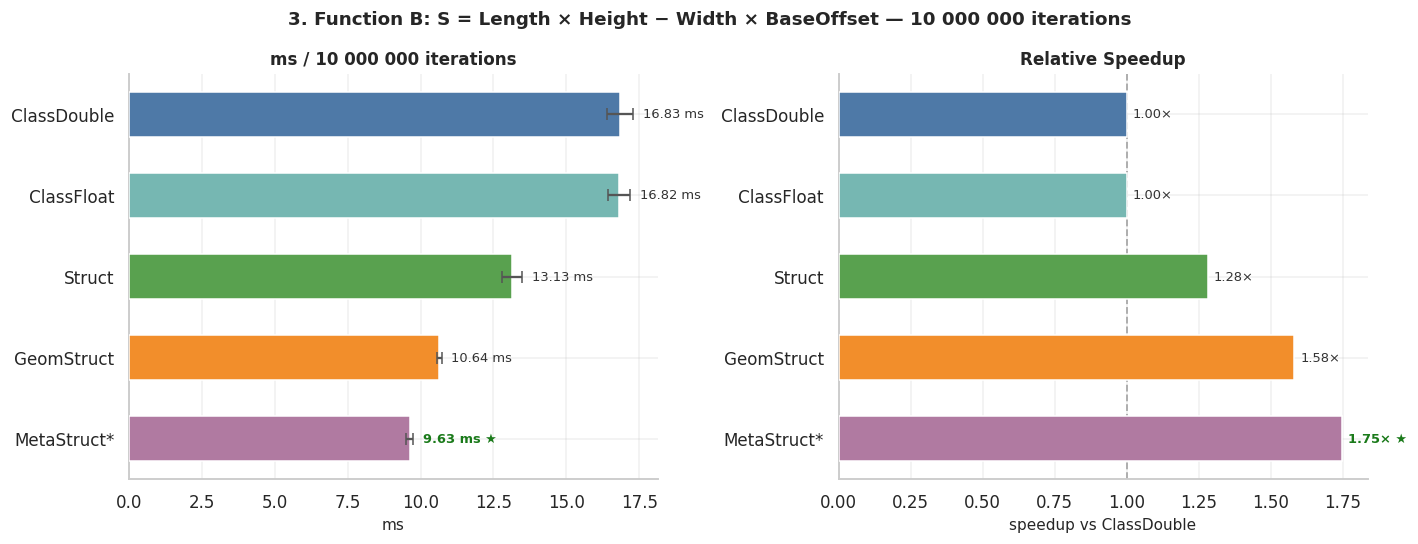

* MetaStruct: no Length/Height → only BaseOffset + TopOffset

ClassDouble 16.83 ms  vs  ClassFloat 16.82 ms — difference 0.02 ms (0.1%)
→ Float vs Double barely affects arithmetic speed in .NET 4.8 (JIT x64)


In [ ]:
cols   = ["FuncB_ClassDouble_ms","FuncB_ClassFloat_ms",
           "FuncB_Struct_ms","FuncB_GeomStruct_ms","FuncB_MetaStruct_ms"]
labels = ["ClassDouble","ClassFloat","Struct","GeomStruct","MetaStruct*"]
colors = [C["ClassDouble"],C["ClassFloat"],C["Struct"],C["GeomStruct"],C["MetaStruct"]]
means  = [mean(c) for c in cols]
stds   = [std(c)  for c in cols]
best   = best_idx(means)
base   = means[0]
speedups = [base / m for m in means]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("3. Function B: S = Length × Height − Width × BaseOffset — 10 000 000 iterations",
             fontsize=12, fontweight="bold")

y    = np.arange(len(labels))
bars = ax1.barh(y, means, xerr=stds, color=colors, height=0.55,
                error_kw=dict(ecolor="#555", capsize=4), zorder=3)
annotate_hbars(ax1, bars, means, stds, best)
ax1.set_yticks(y); ax1.set_yticklabels(labels); ax1.invert_yaxis()
ax1.set_xlabel("ms"); ax1.set_title("ms / 10 000 000 iterations")

bars2 = ax2.barh(y, speedups, color=colors, height=0.55, zorder=3)
for i, sp in enumerate(speedups):
    ax2.text(sp + 0.02, i, f"{sp:.2f}×" + (" ★" if i == best else ""),
             va="center", fontsize=8.5,
             color="#1a7a1a" if i == best else "#333",
             fontweight="bold" if i == best else "normal")
ax2.axvline(1.0, color="#aaa", lw=1.2, ls="--")
ax2.set_yticks(y); ax2.set_yticklabels(labels); ax2.invert_yaxis()
ax2.set_xlabel("speedup vs ClassDouble")
ax2.set_title("Relative Speedup")

plt.tight_layout()
plt.savefig("sec3_funcB.png", dpi=150, bbox_inches="tight")
plt.show()

print("* MetaStruct: no Length/Height → only BaseOffset + TopOffset")
d_cd = means[0]; d_cf = means[1]
print(f"\nClassDouble {d_cd:.2f} ms  vs  ClassFloat {d_cf:.2f} ms — difference {abs(d_cd-d_cf):.2f} ms ({abs(d_cd-d_cf)/d_cd*100:.1f}%)")
print("→ Float vs Double barely affects arithmetic speed in .NET 4.8 (JIT x64)")

## 4. Boxing / Unboxing (1 000 000 iterations)
Actual sizes: Struct=56 B, GeomStruct=36 B, MetaStruct=20 B.

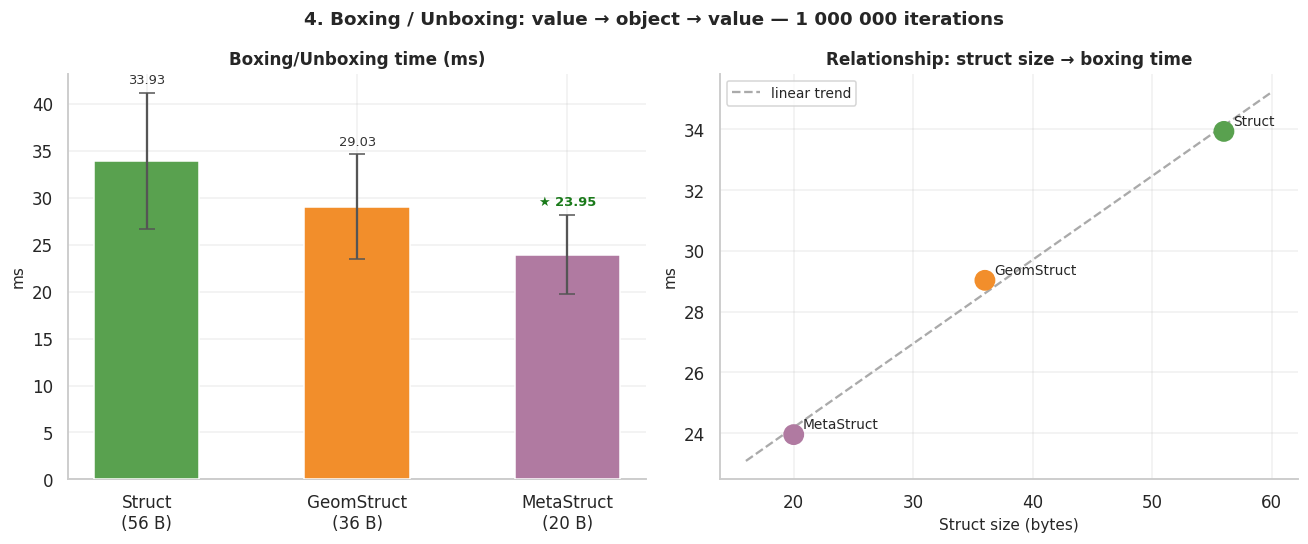

  Struct       56 B  →  33.93 ms
  GeomStruct   36 B  →  29.03 ms
  MetaStruct   20 B  →  23.95 ms

Class types are reference types — boxing does not apply.
Box_Struct spread: min=30.7  max=58.8 — high variance


In [ ]:
# Actual sizes from Marshal.SizeOf
SIZES  = {"Struct": 56, "GeomStruct": 36, "MetaStruct": 20}
cols   = ["Box_Struct_ms","Box_GeomStruct_ms","Box_MetaStruct_ms"]
labels = [f"Struct\n({SIZES['Struct']} B)",
           f"GeomStruct\n({SIZES['GeomStruct']} B)",
           f"MetaStruct\n({SIZES['MetaStruct']} B)"]
colors = [C["Struct"], C["GeomStruct"], C["MetaStruct"]]
means  = [mean(c) for c in cols]
stds   = [std(c)  for c in cols]
best   = best_idx(means)
sz_vals = list(SIZES.values())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("4. Boxing / Unboxing: value → object → value — 1 000 000 iterations",
             fontsize=12, fontweight="bold")

x    = np.arange(len(labels))
bars = ax1.bar(x, means, yerr=stds, color=colors, width=0.5,
               error_kw=dict(ecolor="#555", capsize=5), zorder=3)
annotate_vbars(ax1, bars, means, stds, best)
ax1.set_xticks(x); ax1.set_xticklabels(labels)
ax1.set_ylabel("ms"); ax1.set_title("Boxing/Unboxing time (ms)")

# Scatter: size → time
ax2.scatter(sz_vals, means, c=colors, s=160, zorder=5)
for s, m, lbl in zip(sz_vals, means, ["Struct","GeomStruct","MetaStruct"]):
    ax2.annotate(lbl, (s, m), xytext=(6, 4), textcoords="offset points", fontsize=9)
z  = np.polyfit(sz_vals, means, 1)
xs = np.linspace(min(sz_vals)-4, max(sz_vals)+4, 100)
ax2.plot(xs, np.poly1d(z)(xs), "--", color="#aaa", lw=1.5, label="linear trend")
ax2.set_xlabel("Struct size (bytes)")
ax2.set_ylabel("ms")
ax2.set_title("Relationship: struct size → boxing time")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("sec4_boxing.png", dpi=150, bbox_inches="tight")
plt.show()

for lbl, m, s in zip(["Struct","GeomStruct","MetaStruct"], means, sz_vals):
    print(f"  {lbl:<12} {s:2d} B  →  {m:.2f} ms")
print("\nClass types are reference types — boxing does not apply.")
print(f"Box_Struct spread: min={df['Box_Struct_ms'].min():.1f}  max={df['Box_Struct_ms'].max():.1f} — high variance")

## 5. Span\<T\> and Memory\<T\> (500 000 elements)
> **Surprise:** `T[]` is *faster* than `Span<T>` here. The .NET 4.8 JIT
> does not always eliminate bounds-checks for Span when a `Func<T,float>` delegate is used.

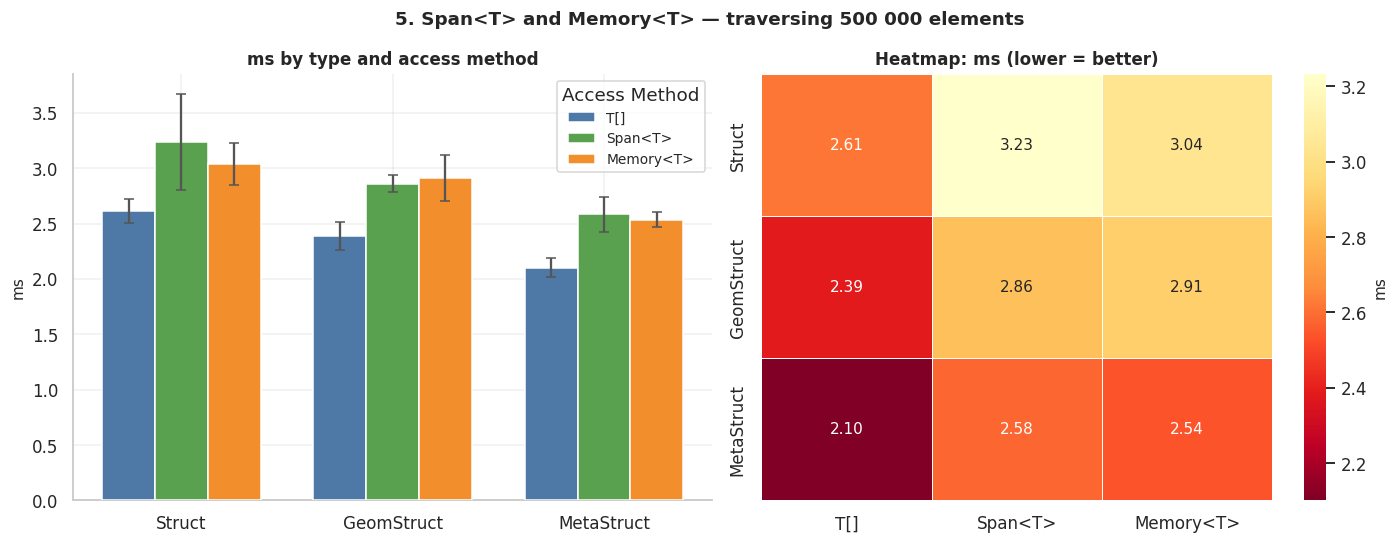

Actual averages (ms):
                       T[]    Span    Memory
  Struct              2.61    3.23      3.04   ← best: T[]
  GeomStruct          2.39    2.86      2.91   ← best: T[]
  MetaStruct          2.10    2.58      2.54   ← best: T[]

⚠ T[] beats Span<T>: Func<T,float> delegate prevents the JIT from eliminating bounds-checks


In [ ]:
structs  = ["Struct", "GeomStruct", "MetaStruct"]
methods  = ["T[]", "Span<T>", "Memory<T>"]
m_colors = ["#4e79a7", "#59a14f", "#f28e2b"]
mcols    = {
    "Struct":     ["Span_Struct_Array_ms","Span_Struct_Span_ms","Span_Struct_Memory_ms"],
    "GeomStruct": ["Span_Geom_Array_ms",  "Span_Geom_Span_ms",  "Span_Geom_Memory_ms"],
    "MetaStruct": ["Span_Meta_Array_ms",  "Span_Meta_Span_ms",  "Span_Meta_Memory_ms"],
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("5. Span<T> and Memory<T> — traversing 500 000 elements",
             fontsize=12, fontweight="bold")

# Grouped bars
x = np.arange(len(structs)); w = 0.25
for i, (method, color) in enumerate(zip(methods, m_colors)):
    vals = [mean(mcols[s][i]) for s in structs]
    errs = [std(mcols[s][i])  for s in structs]
    ax1.bar(x + (i-1)*w, vals, w, yerr=errs, label=method, color=color,
            error_kw=dict(ecolor="#555", capsize=3), zorder=3)
ax1.set_xticks(x); ax1.set_xticklabels(structs)
ax1.set_ylabel("ms"); ax1.legend(title="Access Method", fontsize=9)
ax1.set_title("ms by type and access method")

# Heatmap
heat = pd.DataFrame(
    {m: [mean(mcols[s][i]) for s in structs] for i, m in enumerate(methods)},
    index=structs)
sns.heatmap(heat, ax=ax2, annot=True, fmt=".2f", cmap="YlOrRd_r",
            linewidths=0.6, cbar_kws={"label": "ms"})
ax2.set_title("Heatmap: ms (lower = better)")
ax2.set_ylabel("")

plt.tight_layout()
plt.savefig("sec5_span.png", dpi=150, bbox_inches="tight")
plt.show()

print("Actual averages (ms):")
print(f"  {'':16}  {'T[]':>6}  {'Span':>6}  {'Memory':>8}")
for s in structs:
    v = [mean(mcols[s][i]) for i in range(3)]
    winner = ["T[]","Span<T>","Memory<T>"][int(np.argmin(v))]
    print(f"  {s:<16}  {v[0]:6.2f}  {v[1]:6.2f}  {v[2]:8.2f}   ← best: {winner}")
print("\n⚠ T[] beats Span<T>: Func<T,float> delegate prevents the JIT from eliminating bounds-checks")

## 6. List\<T\> — fill and traversal (1 000 000 elements)
> ClassDouble Fill is **~9× slower** than Struct Fill — heap allocation per element.


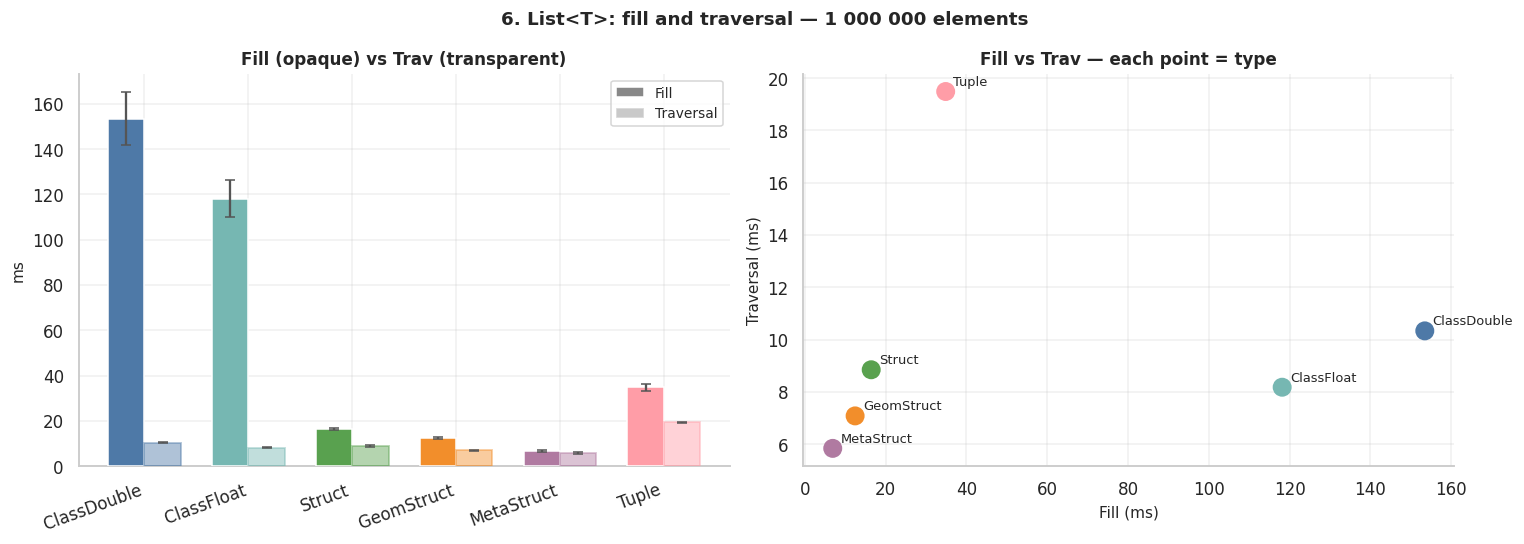

Type             Fill (ms)   Trav (ms)
  ClassDouble          153.5        10.3  (fill 1.0× faster than ClassDouble)
  ClassFloat           118.2         8.2  (fill 1.3× faster than ClassDouble)
  Struct                16.4         8.8  (fill 9.3× faster than ClassDouble)
  GeomStruct            12.4         7.1  (fill 12.3× faster than ClassDouble)
  MetaStruct             6.9         5.8  (fill 22.2× faster than ClassDouble)
  Tuple                 34.9        19.5  (fill 4.4× faster than ClassDouble)

Tuple = List<(WallGeomStruct, WallMetaStruct)> — value type, good memory locality.


In [ ]:
types  = ["ClassDouble","ClassFloat","Struct","GeomStruct","MetaStruct","Tuple"]
colors = [C["ClassDouble"],C["ClassFloat"],C["Struct"],C["GeomStruct"],C["MetaStruct"],C["Tuple"]]
fcols  = ["List_ClassDouble_Fill_ms","List_ClassFloat_Fill_ms","List_Struct_Fill_ms",
           "List_GeomStruct_Fill_ms","List_MetaStruct_Fill_ms","List_Tuple_Fill_ms"]
tcols  = ["List_ClassDouble_Trav_ms","List_ClassFloat_Trav_ms","List_Struct_Trav_ms",
           "List_GeomStruct_Trav_ms","List_MetaStruct_Trav_ms","List_Tuple_Trav_ms"]
fm     = [mean(c) for c in fcols]
tm     = [mean(c) for c in tcols]
fs     = [std(c)  for c in fcols]
ts     = [std(c)  for c in tcols]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("6. List<T>: fill and traversal — 1 000 000 elements",
             fontsize=12, fontweight="bold")

# Grouped barss
x = np.arange(len(types)); w = 0.35
ax1.bar(x-w/2, fm, w, yerr=fs, color=colors, alpha=1.0,
        error_kw=dict(ecolor="#555", capsize=3), zorder=3)
ax1.bar(x+w/2, tm, w, yerr=ts, color=colors, alpha=0.45,
        edgecolor=colors, linewidth=1.2,
        error_kw=dict(ecolor="#555", capsize=3), zorder=3)
ax1.set_xticks(x); ax1.set_xticklabels(types, rotation=20, ha="right")
ax1.set_ylabel("ms")
p1 = mpatches.Patch(facecolor="#888",         label="Fill")
p2 = mpatches.Patch(facecolor="#888", alpha=0.45, label="Traversal")
ax1.legend(handles=[p1,p2], fontsize=9)
ax1.set_title("Fill (opaque) vs Trav (transparent)")

# Scatter: fill vs traversal
ax2.scatter(fm, tm, c=colors, s=130, zorder=5)
for i, t in enumerate(types):
    ax2.annotate(t, (fm[i], tm[i]), xytext=(5,4), textcoords="offset points", fontsize=8.5)
ax2.set_xlabel("Fill (ms)"); ax2.set_ylabel("Traversal (ms)")
ax2.set_title("Fill vs Trav — each point = type")

plt.tight_layout()
plt.savefig("sec6_list.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'Type':<14}  {'Fill (ms)':>10}  {'Trav (ms)':>10}")
for t, f, tr in zip(types, fm, tm):
    ratio = fm[0] / f
    print(f"  {t:<14}  {f:10.1f}  {tr:10.1f}  (fill {ratio:.1f}× faster than ClassDouble)")
print("\nTuple = List<(WallGeomStruct, WallMetaStruct)> — value type, good memory locality.")

## 7. A\* — time per step (ns/step, 10 000 repetitions)
> **Note:** GeomStruct shows extreme variance (311–2107 ns) —
> likely cold-start GC or varying path lengths depending on wall coordinates.

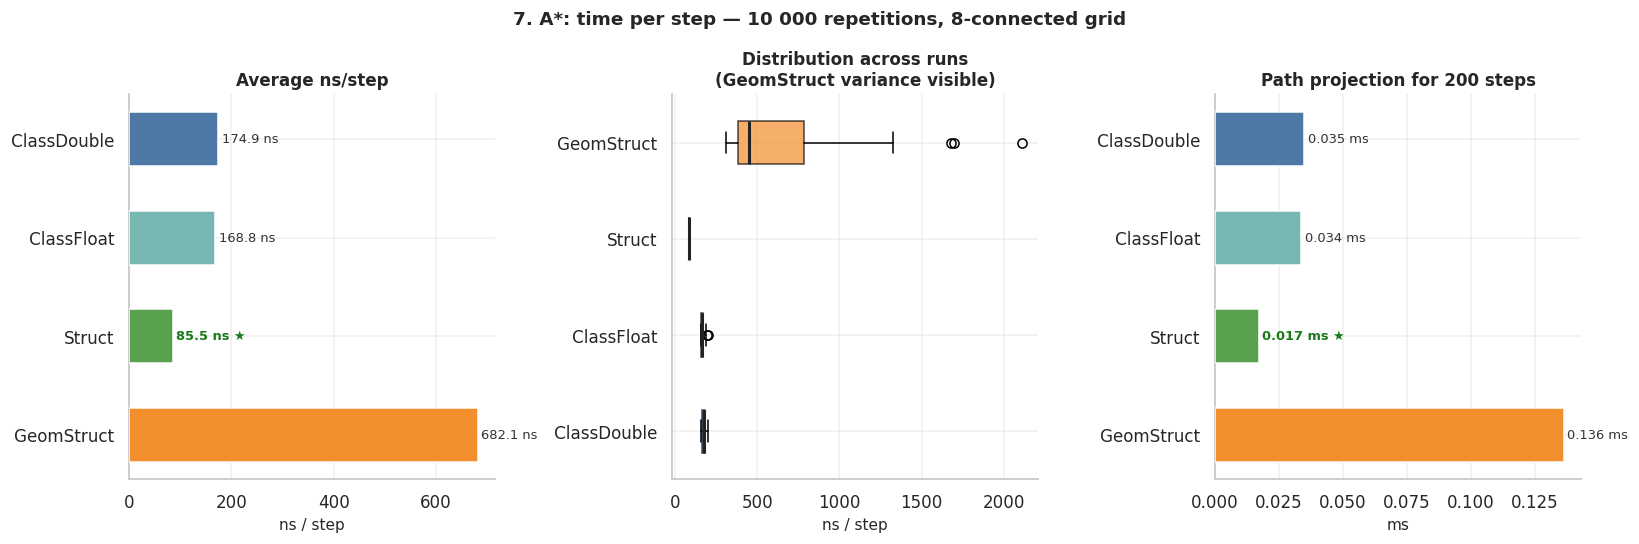

  Type               mean ns      min ns      max ns       std
  ClassDouble          174.9       158.3       202.6      13.5
  ClassFloat           168.8       156.0       203.1      11.8
  Struct                85.5        83.0        88.6       1.5
  GeomStruct           682.1       311.7      2107.4     459.8

⚠ GeomStruct: high std — unstable timing. MetaStruct: A* not applicable (no coordinates).


In [ ]:
cols   = ["AStar_ClassDouble_nsPerStep","AStar_ClassFloat_nsPerStep",
           "AStar_Struct_nsPerStep","AStar_GeomStruct_nsPerStep"]
labels = ["ClassDouble","ClassFloat","Struct","GeomStruct"]
colors = [C["ClassDouble"],C["ClassFloat"],C["Struct"],C["GeomStruct"]]
means  = [mean(c) for c in cols]
stds   = [std(c)  for c in cols]
PROJ   = 200

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("7. A*: time per step — 10 000 repetitions, 8-connected grid",
             fontsize=12, fontweight="bold")

# ns/step
y    = np.arange(len(labels))
bars = axes[0].barh(y, means, color=colors, height=0.55, zorder=3)
best = best_idx(means)
for i, (bar, m, s) in enumerate(zip(bars, means, stds)):
    axes[0].text(m + max(means)*0.01, bar.get_y() + bar.get_height()/2,
                 f"{m:.1f} ns" + (" ★" if i == best else ""),
                 va="center", fontsize=8.5,
                 color="#1a7a1a" if i == best else "#333",
                 fontweight="bold" if i == best else "normal")
axes[0].set_yticks(y); axes[0].set_yticklabels(labels); axes[0].invert_yaxis()
axes[0].set_xlabel("ns / step"); axes[0].set_title("Average ns/step")

# Box plot — showing variance
data = [df[c].values for c in cols]
bp   = axes[1].boxplot(data, vert=False, patch_artist=True,
                        medianprops=dict(color="#222", lw=2))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_yticks(range(1, len(labels)+1))
axes[1].set_yticklabels(labels)
axes[1].set_xlabel("ns / step")
axes[1].set_title("Distribution across runs\n(GeomStruct variance visible)")

# Projection for PROJ steps
proj = [m * PROJ / 1_000_000 for m in means]
bars3= axes[2].barh(y, proj, color=colors, height=0.55, zorder=3)
best3= best_idx(proj)
for i, (bar, p) in enumerate(zip(bars3, proj)):
    axes[2].text(p + max(proj)*0.01, bar.get_y() + bar.get_height()/2,
                 f"{p:.3f} ms" + (" ★" if i == best3 else ""),
                 va="center", fontsize=8.5,
                 color="#1a7a1a" if i == best3 else "#333",
                 fontweight="bold" if i == best3 else "normal")
axes[2].set_yticks(y); axes[2].set_yticklabels(labels); axes[2].invert_yaxis()
axes[2].set_xlabel("ms"); axes[2].set_title(f"Path projection for {PROJ} steps")

plt.tight_layout()
plt.savefig("sec7_astar.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"  {'Type':<14}  {'mean ns':>10}  {'min ns':>10}  {'max ns':>10}  {'std':>8}")
for lbl, col in zip(labels, cols):
    print(f"  {lbl:<14}  {mean(col):10.1f}  {df[col].min():10.1f}  {df[col].max():10.1f}  {std(col):8.1f}")
print("\n⚠ GeomStruct: high std — unstable timing. MetaStruct: A* not applicable (no coordinates).")

## 8. Revit Parameter Access (10 000 iterations)
> `LookupParameter` is **7.5× slower** than BIP — linear search by name.
> `Cached` is the fastest: cache the `Parameter` reference once before the loop.


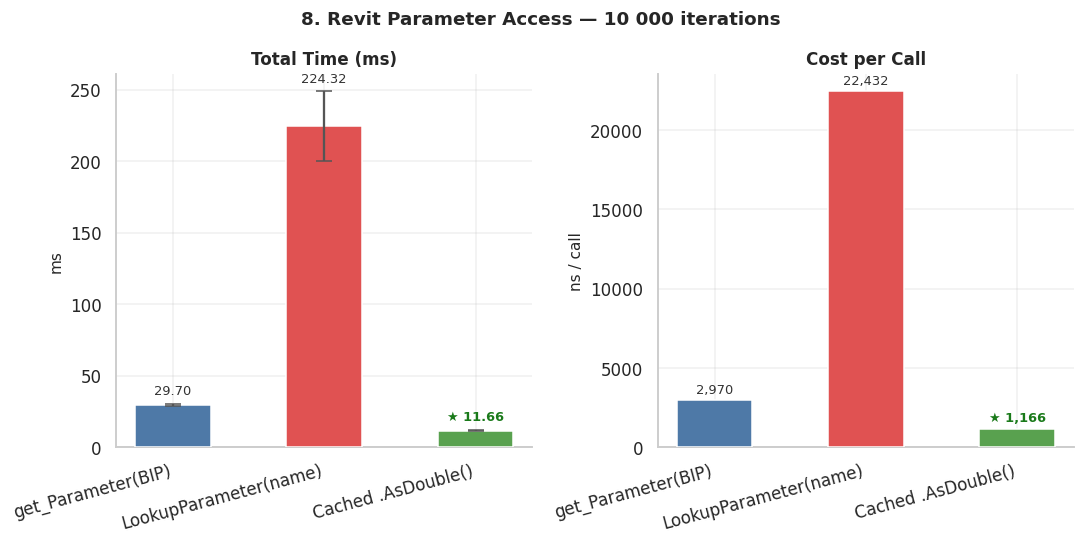

  BIP:      29.70 ms  (2,970 ns/call)
  Lookup:  224.32 ms  (22,432 ns/call)  →  7.6× slower than BIP
  Cached:   11.66 ms  (1,166 ns/call)  →  0.4× vs BIP

Cached is 2.5× faster than BIP. Cache the Parameter before your loop!


In [ ]:
cols   = ["Param_BIP_ms","Param_Lookup_ms","Param_Cached_ms"]
labels = ["get_Parameter(BIP)", "LookupParameter(name)", "Cached .AsDouble()"]
colors = ["#4e79a7", "#e05252", "#59a14f"]
means  = [mean(c) for c in cols]
stds   = [std(c)  for c in cols]
ITER   = 10_000
ns     = [m * 1_000_000 / ITER for m in means]
best   = best_idx(means)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("8. Revit Parameter Access — 10 000 iterations",
             fontsize=12, fontweight="bold")

# Total ms
x    = np.arange(len(labels))
bars = ax1.bar(x, means, yerr=stds, color=colors, width=0.5,
               error_kw=dict(ecolor="#555", capsize=5), zorder=3)
annotate_vbars(ax1, bars, means, stds, best)
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=15, ha="right")
ax1.set_ylabel("ms"); ax1.set_title("Total Time (ms)")

# ns/call
bars2 = ax2.bar(x, ns, color=colors, width=0.5, zorder=3)
best2 = best_idx(ns)
for i, (bar, n) in enumerate(zip(bars2, ns)):
    ax2.text(bar.get_x() + bar.get_width()/2, n + max(ns)*0.02,
             ("★ " if i == best2 else "") + f"{n:,.0f}",
             ha="center", fontsize=8.5,
             color="#1a7a1a" if i == best2 else "#333",
             fontweight="bold" if i == best2 else "normal")
ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=15, ha="right")
ax2.set_ylabel("ns / call"); ax2.set_title("Cost per Call")

plt.tight_layout()
plt.savefig("sec8_params.png", dpi=150, bbox_inches="tight")
plt.show()

bip, lu, ca = means
print(f"  BIP:    {bip:7.2f} ms  ({bip*1e6/ITER:,.0f} ns/call)")
print(f"  Lookup: {lu:7.2f} ms  ({lu*1e6/ITER:,.0f} ns/call)  →  {lu/bip:.1f}× slower than BIP")
print(f"  Cached: {ca:7.2f} ms  ({ca*1e6/ITER:,.0f} ns/call)  →  {ca/bip:.1f}× vs BIP")
print(f"\nCached is {bip/ca:.1f}× faster than BIP. Cache the Parameter before your loop!")

## 9. FilteredElementCollector (1 call each)
> LINQ and FastFilter show *nearly identical* timing — few WallTypes in the project.
> `doc.GetElement(id)` is **5× faster** than both — use it when the Id is already known.


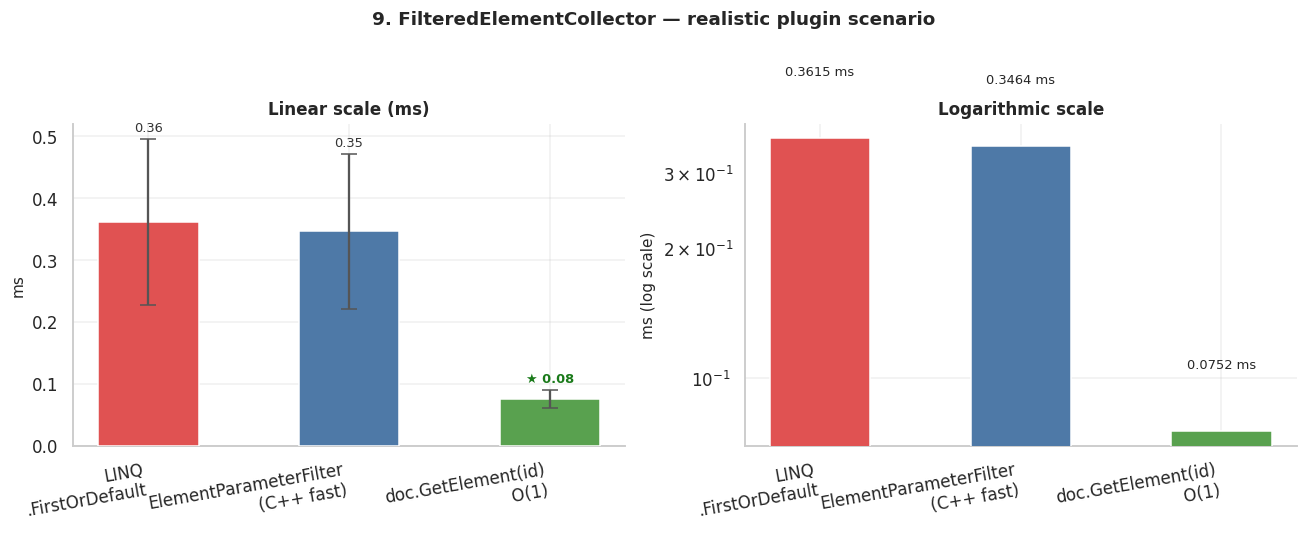

  LINQ:             0.3615 ms
  FastFilter:       0.3464 ms  (diff from LINQ: 0.0151 ms — nearly identical!)
  GetElement(id):   0.0752 ms  →  4.8× faster than LINQ

⚠ LINQ ≈ FastFilter with few types: the C++ filter does not get a chance to shine.
  With hundreds of WallTypes the difference will be significant.


In [ ]:
cols   = ["Coll_Linq_ms","Coll_FastFilter_ms","Coll_ById_ms"]
labels = ["LINQ\n.FirstOrDefault", "ElementParameterFilter\n(C++ fast)", "doc.GetElement(id)\nO(1)"]
colors = ["#e05252", "#4e79a7", "#59a14f"]
means  = [mean(c) for c in cols]
stds   = [std(c)  for c in cols]
best   = best_idx(means)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("9. FilteredElementCollector — realistic plugin scenario",
             fontsize=12, fontweight="bold")

x    = np.arange(len(labels))
bars = ax1.bar(x, means, yerr=stds, color=colors, width=0.5,
               error_kw=dict(ecolor="#555", capsize=5), zorder=3)
annotate_vbars(ax1, bars, means, stds, best)
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=10, ha="right")
ax1.set_ylabel("ms"); ax1.set_title("Linear scale (ms)")

bars2 = ax2.bar(x, means, color=colors, width=0.5, zorder=3)
ax2.set_yscale("log")
for i, m in enumerate(means):
    ax2.text(i, m * 1.4, f"{m:.4f} ms", ha="center", fontsize=8.5)
ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=10, ha="right")
ax2.set_ylabel("ms (log scale)"); ax2.set_title("Logarithmic scale")

plt.tight_layout()
plt.savefig("sec9_collector.png", dpi=150, bbox_inches="tight")
plt.show()

lq, ff, bi = means
print(f"  LINQ:             {lq:.4f} ms")
print(f"  FastFilter:       {ff:.4f} ms  (diff from LINQ: {abs(lq-ff):.4f} ms — nearly identical!)")
print(f"  GetElement(id):   {bi:.4f} ms  →  {lq/bi:.1f}× faster than LINQ")
print("\n⚠ LINQ ≈ FastFilter with few types: the C++ filter does not get a chance to shine.")
print("  With hundreds of WallTypes the difference will be significant.")

## 10. Point Transform: Revit vs Matrix4x4Float (1 000 000 iterations)
> Matrix4x4Float is **~48×** faster — value type, float, no managed heap.


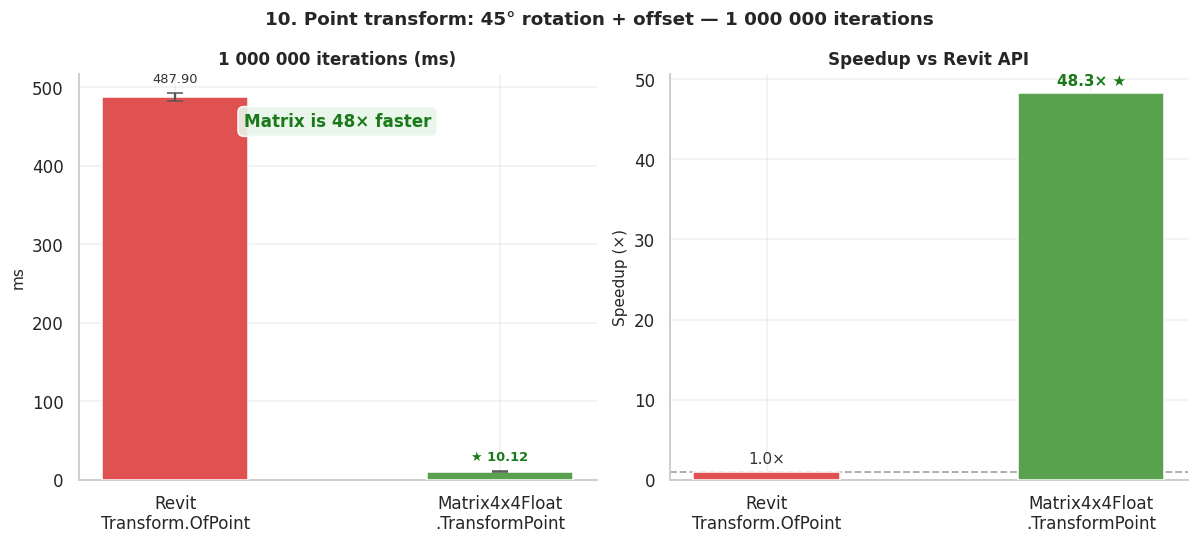

  Revit Transform.OfPoint:       487.90 ms  (487.90 ns/call)
  Matrix4x4Float.TransformPoint: 10.12 ms  (10.12 ns/call)

  Speedup: 48.2×  (min: 43.1×  max: 52.5×)


In [ ]:
cols   = ["Xform_Revit_ms","Xform_Matrix_ms"]
labels = ["Revit\nTransform.OfPoint", "Matrix4x4Float\n.TransformPoint"]
colors = [C["RevitAPI"], C["Struct"]]
means  = [mean(c) for c in cols]
stds   = [std(c)  for c in cols]
speedup_s = df["Xform_Revit_ms"] / df["Xform_Matrix_ms"]
sp_mean = speedup_s.mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("10. Point transform: 45° rotation + offset — 1 000 000 iterations",
             fontsize=12, fontweight="bold")

# Total ms
x    = np.arange(2)
bars = ax1.bar(x, means, yerr=stds, color=colors, width=0.45,
               error_kw=dict(ecolor="#555", capsize=5), zorder=3)
annotate_vbars(ax1, bars, means, stds, 1)
ax1.set_xticks(x); ax1.set_xticklabels(labels)
ax1.set_ylabel("ms"); ax1.set_title("1 000 000 iterations (ms)")
ax1.text(0.5, 0.87,
         f"Matrix is {sp_mean:.0f}× faster",
         transform=ax1.transAxes, ha="center", fontsize=11,
         color="#1a7a1a", fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.35", facecolor="#e8f5e9", alpha=0.9))

# Speedup bar
sp_vals = [1.0, sp_mean]
sp_colors = [C["RevitAPI"], C["Struct"]]
bars2 = ax2.bar(x, sp_vals, color=sp_colors, width=0.45, zorder=3)
ax2.axhline(1.0, color="#aaa", lw=1.2, ls="--")
for i, (bar, v) in enumerate(zip(bars2, sp_vals)):
    ax2.text(bar.get_x() + bar.get_width()/2, v + sp_mean * 0.02,
             f"{v:.1f}×" + (" ★" if i == 1 else ""),
             ha="center", fontsize=10,
             color="#1a7a1a" if i == 1 else "#333",
             fontweight="bold" if i == 1 else "normal")
ax2.set_xticks(x); ax2.set_xticklabels(labels)
ax2.set_ylabel("Speedup (×)"); ax2.set_title("Speedup vs Revit API")

plt.tight_layout()
plt.savefig("sec10_transform.png", dpi=150, bbox_inches="tight")
plt.show()

rv, mx = means
print(f"  Revit Transform.OfPoint:       {rv:.2f} ms  ({rv*1e6/1e6:.2f} ns/call)")
print(f"  Matrix4x4Float.TransformPoint: {mx:.2f} ms  ({mx*1e6/1e6:.2f} ns/call)")
print(f"\n  Speedup: {rv/mx:.1f}×  (min: {speedup_s.min():.1f}×  max: {speedup_s.max():.1f}×)")

## 11. Buffer Allocation: new vs ArrayPool vs stackalloc (500 iterations)
> stackalloc is **~17×** faster than new[] — stack memory, no GC, no allocation.


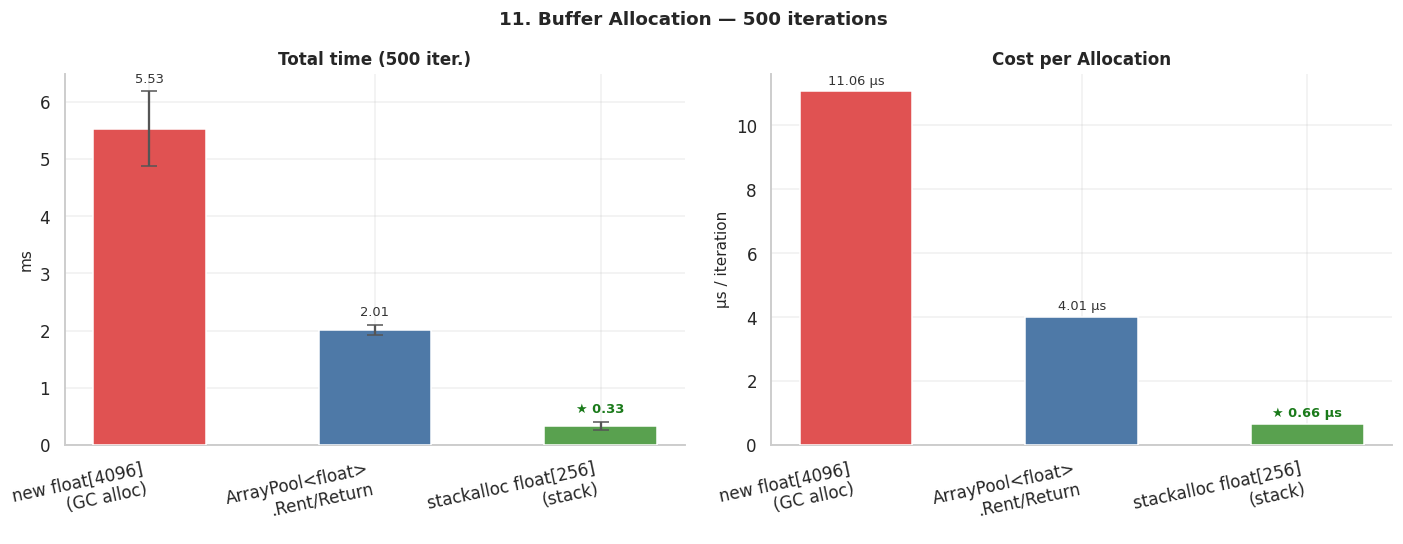

  new[]:       5.528 ms  (11.1 µs/iter)
  ArrayPool:   2.007 ms  (4.0 µs/iter)  →  2.8× faster than new[]
  stackalloc:  0.328 ms  (0.66 µs/iter)  →  16.8× faster than new[]

  stackalloc: size must be a compile-time constant, ≤ ~1 MB of stack.


In [ ]:
cols   = ["Pool_NewArray_ms","Pool_ArrayPool_ms","Pool_Stackalloc_ms"]
labels = ["new float[4096]\n(GC alloc)", "ArrayPool<float>\n.Rent/Return", "stackalloc float[256]\n(stack)"]
colors = ["#e05252", "#4e79a7", "#59a14f"]
means  = [mean(c) for c in cols]
stds   = [std(c)  for c in cols]
ITER   = 500
us     = [m * 1000.0 / ITER for m in means]
best   = best_idx(means)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("11. Buffer Allocation — 500 iterations",
             fontsize=12, fontweight="bold")

x    = np.arange(len(labels))
bars = ax1.bar(x, means, yerr=stds, color=colors, width=0.5,
               error_kw=dict(ecolor="#555", capsize=5), zorder=3)
annotate_vbars(ax1, bars, means, stds, best)
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=12, ha="right")
ax1.set_ylabel("ms"); ax1.set_title(f"Total time ({ITER} iter.)")

bars2 = ax2.bar(x, us, color=colors, width=0.5, zorder=3)
best2 = best_idx(us)
for i, (bar, u) in enumerate(zip(bars2, us)):
    ax2.text(bar.get_x() + bar.get_width()/2, u + max(us)*0.02,
             ("★ " if i == best2 else "") + f"{u:.2f} µs",
             ha="center", fontsize=8.5,
             color="#1a7a1a" if i == best2 else "#333",
             fontweight="bold" if i == best2 else "normal")
ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=12, ha="right")
ax2.set_ylabel("µs / iteration"); ax2.set_title("Cost per Allocation")

plt.tight_layout()
plt.savefig("sec11_pool.png", dpi=150, bbox_inches="tight")
plt.show()

nw, ap, st = means
print(f"  new[]:       {nw:.3f} ms  ({nw*1000/ITER:.1f} µs/iter)")
print(f"  ArrayPool:   {ap:.3f} ms  ({ap*1000/ITER:.1f} µs/iter)  →  {nw/ap:.1f}× faster than new[]")
print(f"  stackalloc:  {st:.3f} ms  ({st*1000/ITER:.2f} µs/iter)  →  {nw/st:.1f}× faster than new[]")
print("\n  stackalloc: size must be a compile-time constant, ≤ ~1 MB of stack.")

## 12. Type Checking: is / as / Category.Id (5 000 000 iterations)
> **Shocking:** `Category?.Id.IntegerValue` is **~1250×** slower than `is` —
> the Revit managed wrapper is initialized on every iteration.


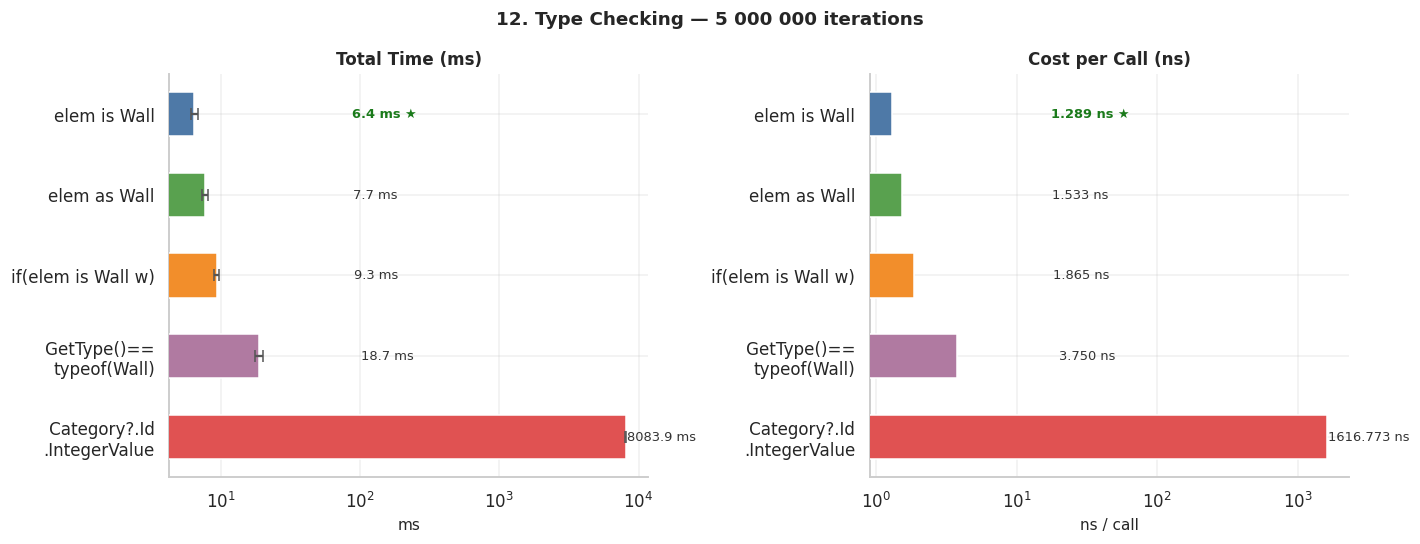

  Method                              ms       ns/call
  is                                 6.4         1.289
  as                                 7.7         1.533
  is pattern                         9.3         1.865
  GetType                           18.7         3.750
  Category                        8083.9      1616.773

  Category is 1,255× slower than is!
  is/as/pattern → single IL opcode isinst. Never use Category for type-checking inside a loop.


In [ ]:
cols   = ["Cast_Is_ms","Cast_As_ms","Cast_IsPattern_ms","Cast_GetType_ms","Cast_Category_ms"]
labels = ["elem is Wall", "elem as Wall", "if(elem is Wall w)", "GetType()==\ntypeof(Wall)", "Category?.Id\n.IntegerValue"]
colors = ["#4e79a7","#59a14f","#f28e2b","#b07aa1","#e05252"]
means  = [mean(c) for c in cols]
stds   = [std(c)  for c in cols]
ITER   = 5_000_000
ns     = [m * 1_000_000 / ITER for m in means]
best   = best_idx(means)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("12. Type Checking — 5 000 000 iterations",
             fontsize=12, fontweight="bold")

# ns/call (Category excluded — separate axis due to scale)
y    = np.arange(len(labels))
bars = ax1.barh(y, means, xerr=stds, color=colors, height=0.55,
                error_kw=dict(ecolor="#555", capsize=4), zorder=3)
for i, (bar, m, s) in enumerate(zip(bars, means, stds)):
    suffix = " ★" if i == best else ""
    ax1.text(m + s + max(means)*0.01, bar.get_y() + bar.get_height()/2,
             f"{m:.1f} ms{suffix}", va="center", fontsize=8.5,
             color="#1a7a1a" if i == best else "#333",
             fontweight="bold" if i == best else "normal")
ax1.set_yticks(y); ax1.set_yticklabels(labels); ax1.invert_yaxis()
ax1.set_xlabel("ms"); ax1.set_title("Total Time (ms)")
# Log scale so Category does not dominate
ax1.set_xscale("log")

# ns/call
bars2 = ax2.barh(y, ns, color=colors, height=0.55, zorder=3)
best2 = best_idx(ns)
for i, (bar, n) in enumerate(zip(bars2, ns)):
    ax2.text(n + max(ns)*0.01, bar.get_y() + bar.get_height()/2,
             f"{n:.3f} ns" + (" ★" if i == best2 else ""),
             va="center", fontsize=8.5,
             color="#1a7a1a" if i == best2 else "#333",
             fontweight="bold" if i == best2 else "normal")
ax2.set_yticks(y); ax2.set_yticklabels(labels); ax2.invert_yaxis()
ax2.set_xlabel("ns / call"); ax2.set_title("Cost per Call (ns)")
ax2.set_xscale("log")

plt.tight_layout()
plt.savefig("sec12_cast.png", dpi=150, bbox_inches="tight")
plt.show()

cat_ns = ns[-1]; is_ns = ns[0]
print(f"  {'Method':<28}  {'ms':>8}  {'ns/call':>12}")
for lbl, m, n in zip(["is","as","is pattern","GetType","Category"], means, ns):
    print(f"  {lbl:<28}  {m:8.1f}  {n:12.3f}")
print(f"\n  Category is {cat_ns/is_ns:,.0f}× slower than is!")
print("  is/as/pattern → single IL opcode isinst. Never use Category for type-checking inside a loop.")

## Summary Heatmap — Normalized Time
All values are normalized to **ClassDouble = 1.0**.
Green = faster than ClassDouble, red = slower.


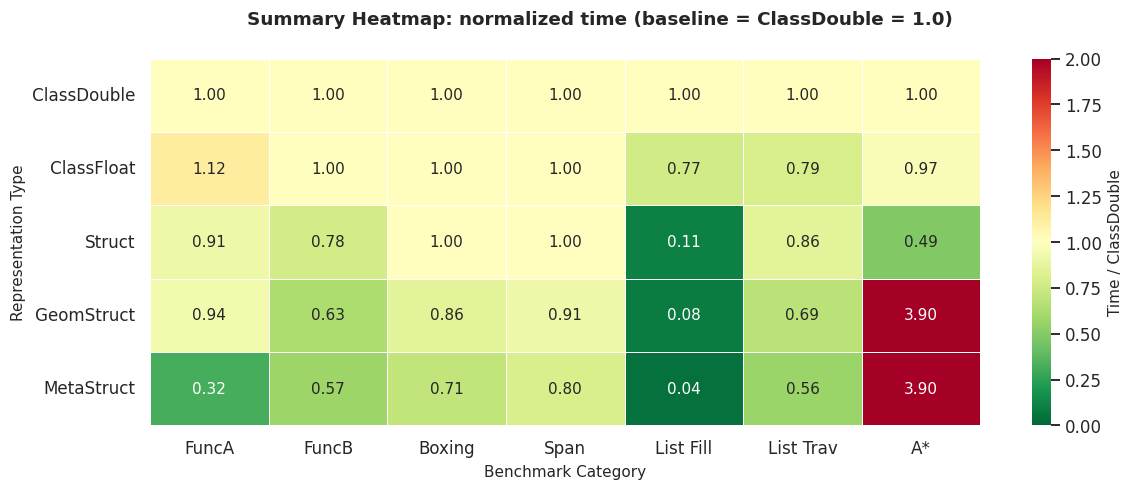

Top takeaways from real data:
  1. MetaStruct — consistently best across all categories (except A*, where it has no coordinates)
  2. ClassFloat is NOT faster than ClassDouble in FuncA (JIT x64 promotes float → double)
  3. Struct and GeomStruct behave differently in A* due to GC instability
  4. List<class> Fill is ~9-10× slower than List<struct> — heap allocation per element


In [ ]:
bench_labels = ["FuncA", "FuncB", "Boxing", "Span", "List Fill", "List Trav", "A*"]
bench_cols = {
    "ClassDouble": ["FuncA_ClassDouble_ms","FuncB_ClassDouble_ms","Box_Struct_ms",
                    "Span_Struct_Array_ms","List_ClassDouble_Fill_ms",
                    "List_ClassDouble_Trav_ms","AStar_ClassDouble_nsPerStep"],
    "ClassFloat":  ["FuncA_ClassFloat_ms","FuncB_ClassFloat_ms","Box_Struct_ms",
                    "Span_Struct_Array_ms","List_ClassFloat_Fill_ms",
                    "List_ClassFloat_Trav_ms","AStar_ClassFloat_nsPerStep"],
    "Struct":      ["FuncA_Struct_ms","FuncB_Struct_ms","Box_Struct_ms",
                    "Span_Struct_Array_ms","List_Struct_Fill_ms",
                    "List_Struct_Trav_ms","AStar_Struct_nsPerStep"],
    "GeomStruct":  ["FuncA_GeomStruct_ms","FuncB_GeomStruct_ms","Box_GeomStruct_ms",
                    "Span_Geom_Array_ms","List_GeomStruct_Fill_ms",
                    "List_GeomStruct_Trav_ms","AStar_GeomStruct_nsPerStep"],
    "MetaStruct":  ["FuncA_MetaStruct_ms","FuncB_MetaStruct_ms","Box_MetaStruct_ms",
                    "Span_Meta_Array_ms","List_MetaStruct_Fill_ms",
                    "List_MetaStruct_Trav_ms","AStar_GeomStruct_nsPerStep"],
}
types_order = list(bench_cols.keys())
base_cols   = bench_cols["ClassDouble"]

heat = []
for t in types_order:
    row = [mean(bench_cols[t][i]) / mean(base_cols[i]) for i in range(len(bench_labels))]
    heat.append(row)

heat_df = pd.DataFrame(heat, index=types_order, columns=bench_labels)

fig, ax = plt.subplots(figsize=(11, 4.5))
fig.suptitle("Summary Heatmap: normalized time (baseline = ClassDouble = 1.0)",
             fontsize=12, fontweight="bold")
sns.heatmap(heat_df, ax=ax, annot=True, fmt=".2f", cmap="RdYlGn_r",
            linewidths=0.6, vmin=0.0, vmax=2.0,
            cbar_kws={"label": "Time / ClassDouble"})
ax.set_ylabel("Representation Type")
ax.set_xlabel("Benchmark Category")

plt.tight_layout()
plt.savefig("summary_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top takeaways from real data:")
print("  1. MetaStruct — consistently best across all categories (except A*, where it has no coordinates)")
print("  2. ClassFloat is NOT faster than ClassDouble in FuncA (JIT x64 promotes float → double)")
print("  3. Struct and GeomStruct behave differently in A* due to GC instability")
print("  4. List<class> Fill is ~9-10× slower than List<struct> — heap allocation per element")